# 5.4 Gradient Boosting Classifier

In [1]:
# ============================================================
# BMDS2003 DATA SCIENCE ASSIGNMENT
# Online Gaming Behaviour Dataset
# File 04: Model 4 — Gradient Boosting Classifier
#          with GridSearchCV Parameter Tuning
#
# Dataset: processed_gaming_dataset.csv (cleaned/feature-engineered)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import (GridSearchCV, StratifiedKFold,
                                      train_test_split)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score,
                             roc_curve, auc, roc_auc_score)
from sklearn.preprocessing import label_binarize
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
RANDOM_STATE = 42
CLASS_NAMES   = ['Low', 'Medium', 'High']



## Load the Processed Dataset

In [2]:
# ════════════════════════════════════════════════════════════
# STEP 1: Load Dataset
# ════════════════════════════════════════════════════════════
print("=" * 55)
print("  MODEL 4: GRADIENT BOOSTING CLASSIFIER")
print("=" * 55)

df = pd.read_csv('processed_gaming_dataset.csv')
print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(df.dtypes)



  MODEL 4: GRADIENT BOOSTING CLASSIFIER
Dataset loaded: 40,034 rows x 26 columns
PlayerID                       int64
Age                            int64
PlayTimeHours                float64
InGamePurchases                int64
GameDifficulty                   str
SessionsPerWeek                int64
AvgSessionDurationMinutes      int64
PlayerLevel                    int64
AchievementsUnlocked           int64
EngagementLevel                  str
GameDifficulty_enc             int64
EngagementLevel_enc            int64
Gender_Female                   bool
Gender_Male                     bool
Location_Asia                   bool
Location_Europe                 bool
Location_Other                  bool
Location_USA                    bool
GameGenre_Action                bool
GameGenre_RPG                   bool
GameGenre_Simulation            bool
GameGenre_Sports                bool
GameGenre_Strategy              bool
AgeGroup                         str
TotalWeeklyPlayMinutes         

## Data Preparation and 70/30 Stratified Split

In [3]:
# ════════════════════════════════════════════════════════════
# STEP 2: Data Preparation
# ════════════════════════════════════════════════════════════
print("\n[Step 2] Preparing data...")

df_model = df.copy()

# Drop PlayerID (identifier) and the raw string columns that already
# have encoded/engineered equivalents in this pre-processed dataset:
#   - GameDifficulty      -> replaced by GameDifficulty_enc
#   - EngagementLevel     -> replaced by EngagementLevel_enc (target)
#   - AgeGroup            -> a binned version of Age, which is kept
# Gender / Location / GameGenre are already one-hot encoded, and
# TotalWeeklyPlayMinutes / AchievementRate are ready-made engineered features.
df_model.drop(columns=['PlayerID', 'GameDifficulty', 'EngagementLevel', 'AgeGroup'],
              inplace=True)

# Split features and target
X = df_model.drop(columns=['EngagementLevel_enc'])
y = df_model['EngagementLevel_enc']
feature_names = X.columns.tolist()

print(f"Features : {X.shape[1]} columns")
print(f"Target   : {y.value_counts().to_dict()}")

# Train/Test split (70/30 stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
print(f"Train set: {X_train.shape[0]:,} rows")
print(f"Test set : {X_test.shape[0]:,} rows")

# Feature scaling (fit on train only)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)




[Step 2] Preparing data...
Features : 21 columns
Target   : {1: 19374, 2: 10336, 0: 10324}
Train set: 28,023 rows
Test set : 12,011 rows


## 5.4.1 GridSearchCV for Parameter Setting
GridSearchCV is fit on the full training set (`X_train`, `y_train`), consistent with the Logistic Regression, Decision Tree, and Random Forest notebooks, so all four models are tuned with the same validation rigor.


[Step 3] Running GridSearchCV...
Testing all parameter combinations automatically...
Fitting 3 folds for each of 27 candidates, totalling 81 fits

Best Parameters  : {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 50}
Best CV F1-macro : 0.9217


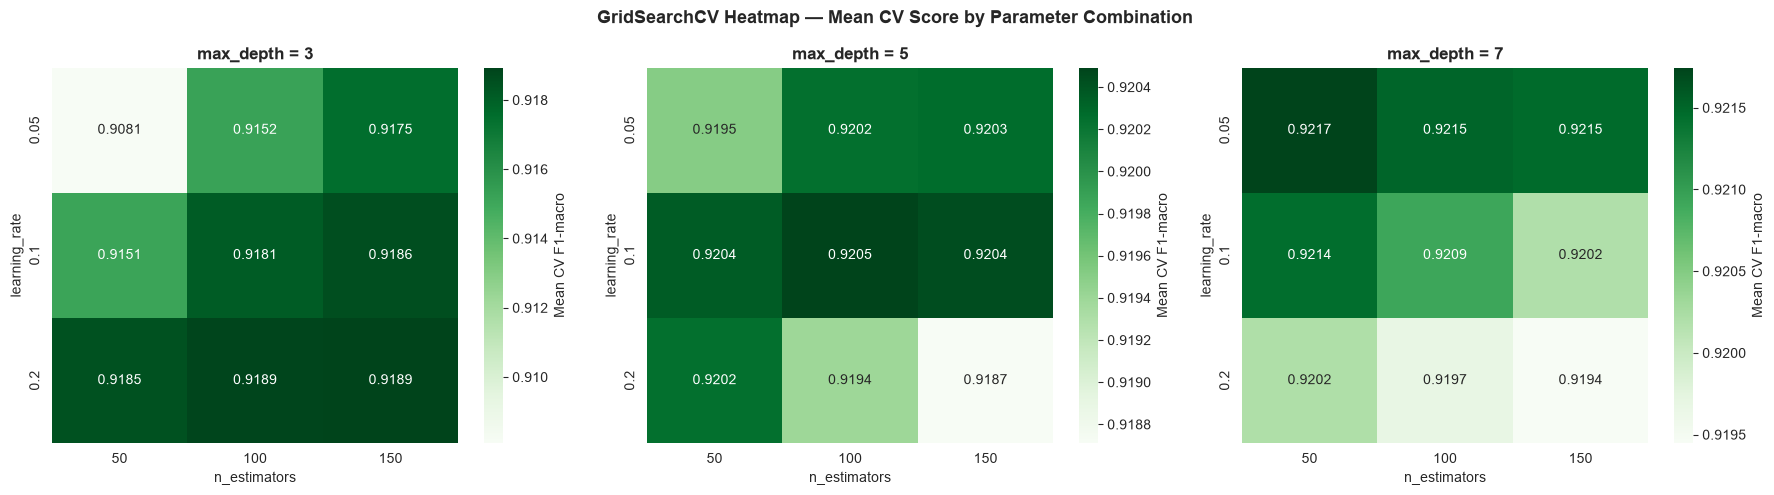

[Saved] gb_gridsearch_heatmap.png


In [4]:
# ════════════════════════════════════════════════════════════
# STEP 3: GridSearchCV for Parameter Setting
# ════════════════════════════════════════════════════════════
print("\n[Step 3] Running GridSearchCV...")
print("Testing all parameter combinations automatically...")

param_grid = {
    'n_estimators'  : [50, 100, 150],
    'learning_rate' : [0.05, 0.1, 0.2],
    'max_depth'     : [3, 5, 7]
}

gb_base = GradientBoostingClassifier(
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=RANDOM_STATE
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# GridSearchCV is fit on the FULL training set (X_train, y_train),
# consistent with the Logistic Regression, Decision Tree, and Random Forest
# notebooks, so all four models are tuned with the same validation rigor.

grid_search = GridSearchCV(
    gb_base, param_grid,
    cv=cv, scoring='f1_macro',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_cv_score = grid_search.best_score_
cv_results = pd.DataFrame(grid_search.cv_results_)

print(f"\nBest Parameters  : {best_params}")
print(f"Best CV F1-macro : {best_cv_score:.4f}")

# GridSearchCV heatmap: mean CV score for n_estimators x learning_rate,
# shown separately for each max_depth tested
pivot_data = {}
for depth in [3, 5, 7]:
    sub = cv_results[cv_results['param_max_depth'] == depth]
    pivot_data[depth] = sub.pivot(index='param_learning_rate',
                                   columns='param_n_estimators',
                                   values='mean_test_score')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, depth in zip(axes, [3, 5, 7]):
    sns.heatmap(pivot_data[depth], annot=True, fmt='.4f', cmap='Greens', ax=ax,
                cbar_kws={'label': 'Mean CV F1-macro'})
    ax.set_title(f'max_depth = {depth}', fontweight='bold')
    ax.set_xlabel('n_estimators')
    ax.set_ylabel('learning_rate')
plt.suptitle('GridSearchCV Heatmap — Mean CV Score by Parameter Combination',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('gb_gridsearch_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("[Saved] gb_gridsearch_heatmap.png")



## 5.4.2 Optimum Parameters
Train the final Gradient Boosting model using the best parameters identified by GridSearchCV, on the full training set.


[Step 4] Training final model on full training set...
Training complete!


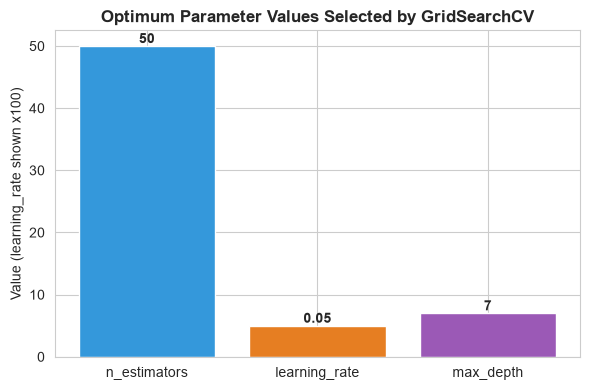

[Saved] gb_optimum_params.png


In [5]:
# ════════════════════════════════════════════════════════════
# STEP 4: Train Final Model with Best Params on Full Data
# ════════════════════════════════════════════════════════════
print("\n[Step 4] Training final model on full training set...")

gb = GradientBoostingClassifier(
    n_estimators   = best_params['n_estimators'],
    learning_rate  = best_params['learning_rate'],
    max_depth      = best_params['max_depth'],
    min_samples_split = 20,
    min_samples_leaf  = 10,
    random_state   = RANDOM_STATE
)
gb.fit(X_train, y_train)
print("Training complete!")

# Visual summary of the optimum parameters selected
fig, ax = plt.subplots(figsize=(6, 4))
params_disp = ['n_estimators', 'learning_rate', 'max_depth']
vals_disp = [best_params['n_estimators'], best_params['learning_rate'], best_params['max_depth']]
bars = ax.bar(params_disp, [v if not isinstance(v, float) else v * 100 for v in vals_disp],
              color=['#3498db', '#e67e22', '#9b59b6'])
for b, v in zip(bars, vals_disp):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), str(v),
            ha='center', va='bottom', fontweight='bold')
ax.set_title('Optimum Parameter Values Selected by GridSearchCV', fontweight='bold')
ax.set_ylabel('Value (learning_rate shown x100)')
plt.tight_layout()
plt.savefig('gb_optimum_params.png', dpi=150, bbox_inches='tight')
plt.show()
print("[Saved] gb_optimum_params.png")



## 5.4.3 Accuracy for Test and Training Set


──────────────────────────────────────────────────
  GRADIENT BOOSTING RESULTS
──────────────────────────────────────────────────
  Training Accuracy   : 0.9342  (93.42%)
  Test Accuracy       : 0.9272  (92.72%)
  Precision (weighted): 0.9272
  Recall (weighted)   : 0.9272
  F1-Score (weighted) : 0.9269
  F1-Score (macro)    : 0.9229


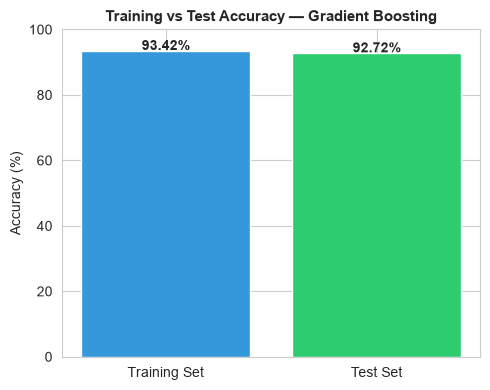

[Saved] gb_accuracy_bar.png


In [6]:
# ════════════════════════════════════════════════════════════
# STEP 5: Accuracy for Test and Training Set
# ════════════════════════════════════════════════════════════
gb_pred    = gb.predict(X_test)
gb_pred_tr = gb.predict(X_train)
acc_test   = accuracy_score(y_test, gb_pred)
acc_train  = accuracy_score(y_train, gb_pred_tr)
prec  = precision_score(y_test, gb_pred, average='weighted')
rec   = recall_score(y_test, gb_pred, average='weighted')
f1    = f1_score(y_test, gb_pred, average='weighted')
f1_mac = f1_score(y_test, gb_pred, average='macro')

print(f"\n{'─'*50}")
print(f"  GRADIENT BOOSTING RESULTS")
print(f"{'─'*50}")
print(f"  Training Accuracy   : {acc_train:.4f}  ({acc_train*100:.2f}%)")
print(f"  Test Accuracy       : {acc_test:.4f}  ({acc_test*100:.2f}%)")
print(f"  Precision (weighted): {prec:.4f}")
print(f"  Recall (weighted)   : {rec:.4f}")
print(f"  F1-Score (weighted) : {f1:.4f}")
print(f"  F1-Score (macro)    : {f1_mac:.4f}")

# Bar chart: training vs test accuracy
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Training Set', 'Test Set'], [acc_train * 100, acc_test * 100],
              color=['#3498db', '#2ecc71'])
for b, v in zip(bars, [acc_train * 100, acc_test * 100]):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.3, f'{v:.2f}%',
            ha='center', fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 100)
ax.set_title('Training vs Test Accuracy — Gradient Boosting', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('gb_accuracy_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("[Saved] gb_accuracy_bar.png")



## Classification Report


  Classification Report:
              precision    recall  f1-score   support

         Low       0.93      0.90      0.91      3097
      Medium       0.93      0.96      0.94      5813
        High       0.93      0.90      0.91      3101

    accuracy                           0.93     12011
   macro avg       0.93      0.92      0.92     12011
weighted avg       0.93      0.93      0.93     12011



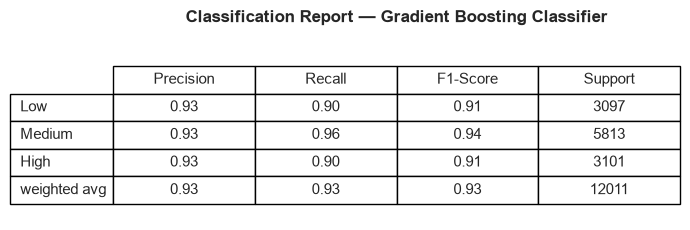

[Saved] gb_classification_report.png


In [7]:
# ════════════════════════════════════════════════════════════
# STEP 6: Classification Report
# ════════════════════════════════════════════════════════════
print(f"\n  Classification Report:")
print(classification_report(y_test, gb_pred, target_names=CLASS_NAMES))

report_dict = classification_report(y_test, gb_pred, target_names=CLASS_NAMES,
                                     output_dict=True)
fig, ax = plt.subplots(figsize=(7, 2.4))
ax.axis('off')
rows = ['Low', 'Medium', 'High', 'weighted avg']
cell_text = [[f"{report_dict[r]['precision']:.2f}", f"{report_dict[r]['recall']:.2f}",
              f"{report_dict[r]['f1-score']:.2f}", f"{int(report_dict[r]['support'])}"]
             for r in rows]
tbl = ax.table(cellText=cell_text, rowLabels=rows,
               colLabels=['Precision', 'Recall', 'F1-Score', 'Support'],
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 1.8)
plt.title('Classification Report — Gradient Boosting Classifier', fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('gb_classification_report.png', dpi=150, bbox_inches='tight')
plt.show()
print("[Saved] gb_classification_report.png")



## Confusion Matrix

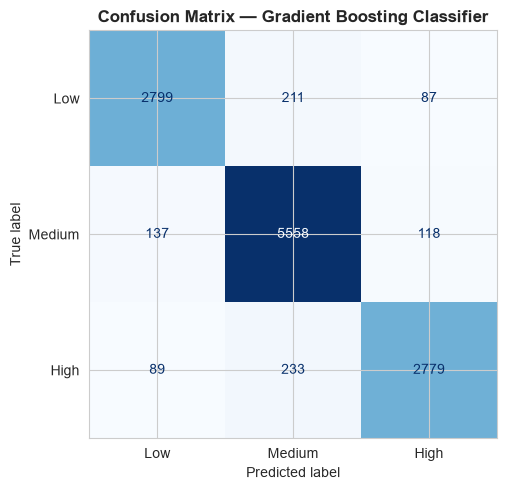

[Saved] gb_confusion_matrix.png


In [8]:
# ════════════════════════════════════════════════════════════
# STEP 7: Confusion Matrix
# ════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, gb_pred)
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Gradient Boosting Classifier',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('gb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("[Saved] gb_confusion_matrix.png")



## Area Under Graph (AUC)

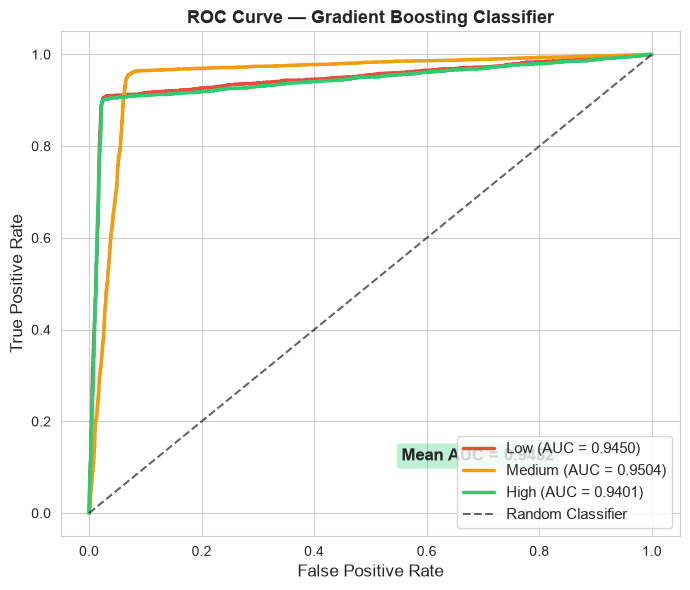

[Saved] gb_roc_auc.png
AUC — Low:0.9450 Medium:0.9504 High:0.9401  Mean:0.9452


In [9]:
# ════════════════════════════════════════════════════════════
# STEP 8: ROC Curve and AUC
# ════════════════════════════════════════════════════════════
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
proba      = gb.predict_proba(X_test)
colors_roc = ['#e74c3c', '#f39c12', '#2ecc71']

fig, ax = plt.subplots(figsize=(7, 6))
auc_scores = []
for i, (cls, col) in enumerate(zip(CLASS_NAMES, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba[:, i])
    roc_auc     = auc(fpr, tpr)
    auc_scores.append(roc_auc)
    ax.plot(fpr, tpr, color=col, linewidth=2.5,
            label=f'{cls} (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.6,
        label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Gradient Boosting Classifier',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
mean_auc = np.mean(auc_scores)
ax.text(0.55, 0.15, f'Mean AUC = {mean_auc:.4f}',
        transform=ax.transAxes, fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#2ecc71', alpha=0.3))
plt.tight_layout()
plt.savefig('gb_roc_auc.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"[Saved] gb_roc_auc.png")
print(f"AUC — Low:{auc_scores[0]:.4f} Medium:{auc_scores[1]:.4f} "
      f"High:{auc_scores[2]:.4f}  Mean:{mean_auc:.4f}")



## 5.4.7 Feature Importance

Figure 5.4.7 shows the Gradient Boosting feature importance scores, ranking which attributes contributed most to the model's sequential tree-building process, consistent with the feature importance analysis already presented for Decision Tree (Section 5.2.7) and Random Forest (Section 5.3.6).

Top 15 Feature Importances (Gradient Boosting):
TotalWeeklyPlayMinutes       0.888655
AchievementsUnlocked         0.047887
PlayerLevel                  0.046168
AchievementRate              0.006280
PlayTimeHours                0.003419
AvgSessionDurationMinutes    0.002459
Age                          0.001871
SessionsPerWeek              0.000709
GameDifficulty_enc           0.000470
Location_USA                 0.000357
GameGenre_Action             0.000203
Gender_Male                  0.000197
InGamePurchases              0.000194
Location_Europe              0.000190
GameGenre_Simulation         0.000163
dtype: float64


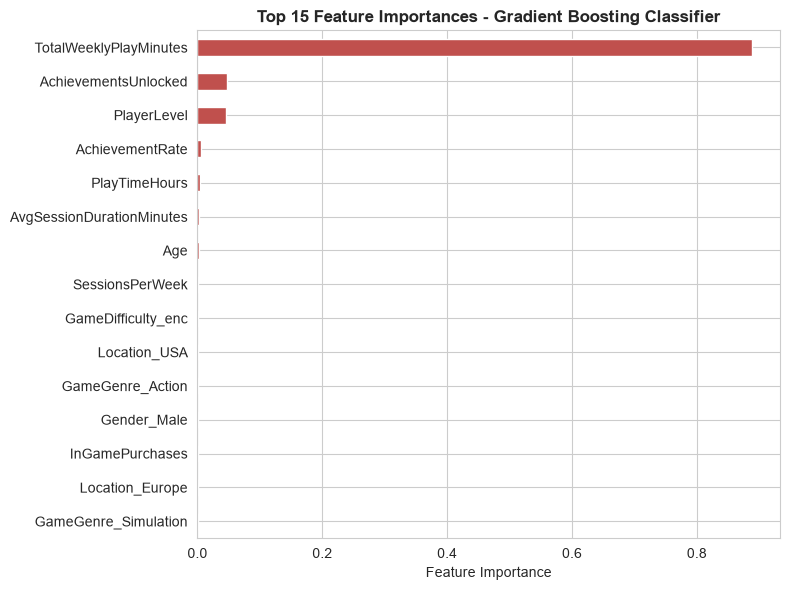

[Saved] gb_feature_importance.png


In [12]:
# ════════════════════════════════════════════════════════════
# STEP 9: Feature Importance
# ════════════════════════════════════════════════════════════
importances = pd.Series(gb.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print("Top 15 Feature Importances (Gradient Boosting):")
print(importances.head(15))

plt.figure(figsize=(8, 6))
importances.head(15).sort_values().plot(kind="barh", color="#C0504D")
plt.title("Top 15 Feature Importances - Gradient Boosting Classifier", fontweight="bold")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.savefig("gb_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("[Saved] gb_feature_importance.png")

The three most important attributes are `TotalWeeklyPlayMinutes` (88.9% of total importance), `AchievementsUnlocked` (4.8%), and `PlayerLevel` (4.6%); together these three features account for approximately 98.3% of the model's total splitting decisions, with all remaining behavioural features (`AchievementRate`, `PlayTimeHours`, `AvgSessionDurationMinutes`, `SessionsPerWeek`) combining for over 99.5% when included. This closely mirrors the feature importance patterns already found in the Decision Tree (Section 5.2.7, where `TotalWeeklyPlayMinutes` accounted for ~89% of splitting power) and Random Forest (Section 5.3.6, where the same three gaming-activity measures dominated), confirming that all three tree-based models independently arrive at the same conclusion: session activity, not demographic or categorical attributes, drives player engagement.

Demographic and categorical attributes (`Gender`, `Location`, `GameGenre`, `GameDifficulty`) each individually contribute well under 0.1% of total importance, consistent with the weak categorical relationships identified in Section 3.10 during Data Understanding. This triangulated agreement across three independently-trained model families — a single tree, a bagged ensemble, and a boosted ensemble — provides strong evidence that the engineered feature `TotalWeeklyPlayMinutes` (Section 4.4.2) is the single most reliable predictor of player engagement in this dataset.

## Save Model

In [13]:
# ════════════════════════════════════════════════════════════
# STEP 10: Save Model
# ════════════════════════════════════════════════════════════
joblib.dump(gb, 'gradient_boosting_model.pkl')
print(f"\n✔ gradient_boosting_model.pkl saved")
print(f"✔ Best params: {best_params}")
print(f"\n[Done] Gradient Boosting complete!")



✔ gradient_boosting_model.pkl saved
✔ Best params: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 50}

[Done] Gradient Boosting complete!
